In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv("C:/Users/LSG/Desktop/AICE_자료/AICE_Associate_실습코드/Clean_Dataset.csv")


In [10]:

# 0번째 컬럼을 열 단위로 지우고 바로 적용
df.drop([df.columns[0]], axis=1, inplace=True)

In [11]:
# 수치형 데이터의 요약 통계량 확인하기
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [12]:
# 문자형 혹은 범주형 데이터의 경우 include='all' 을 통해 해당 칼럼에 대한 요약 통계량도 함께 확인할 수 있음
# 전체 컬럼 요약 통계량 확인
df.describe(include='all')

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
count,300153,300153,300153,300153,300153,300153,300153,300153,300153.000000,300153.000000,300153.000000
unique,6,1561,6,6,3,6,6,2,NaN,NaN,NaN
top,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy,NaN,NaN,NaN
freq,127859,3235,61343,71146,250863,91538,59097,206666,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.221021,26.004751,20889.660523
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.191997,13.561004,22697.767366
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.830000,1.000000,1105.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.830000,15.000000,4783.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.250000,26.000000,7425.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.170000,38.000000,42521.000000


In [13]:
# 빈도표 확인
print(df['airline'].value_counts())
print(df['source_city'].value_counts())
print(df['destination_city'].value_counts())

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64
source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64
destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64


In [14]:
# 상관계수 (heatmap 에 활용)
# +1 -> 강한 양의 상관관계
# -1 -> 강한 음의 상관관계
df.corr(numeric_only=True)

,duration,days_left,price
duration,1.000000,-0.039157,0.204222
days_left,-0.039157,1.000000,-0.091949
price,0.204222,-0.091949,1.000000


In [15]:
# Economy로 class를 한정하여 새로운 데이터 프레임 생성
df_eco = df[(df['class']=='Economy')]
df_eco.corr(numeric_only=True)

,duration,days_left,price
duration,1.000000,-0.042537,0.288379
days_left,-0.042537,1.000000,-0.559551
price,0.288379,-0.559551,1.000000


In [16]:
df_test = df[(df['airline']=='Vistara')]
df_test.corr(numeric_only=True)

,duration,days_left,price
duration,1.000000,-0.032839,0.057582
days_left,-0.032839,1.000000,-0.068856
price,0.057582,-0.068856,1.000000


In [17]:
# 교차표 확인 crosstab
# 출발 도시와 출발 시간 두 범주형 변수의 관계 확인하기 
pd.crosstab(df['source_city'], df['departure_time'])

departure_time,Afternoon,Early_Morning,Evening,Late_Night,Morning,Night
source_city,,,,,,
Bangalore,5183,13611,14243,457,12323,6244
Chennai,5807,9319,5402,72,10550,7550
Delhi,11234,12248,16790,357,13679,7035
Hyderabad,7221,8524,5991,38,9923,9109
Kolkata,7863,8133,9594,114,12065,8578
Mumbai,10486,14955,13082,268,12606,9499


In [18]:
pd.crosstab(df['airline'], df['class'])

class,Business,Economy
airline,,
AirAsia,0,16098
Air_India,32898,47994
GO_FIRST,0,23173
Indigo,0,43120
SpiceJet,0,9011
Vistara,60589,67270


In [19]:
days_left = df.groupby('days_left').mean(numeric_only=True)
days_left.head()

,duration,price
days_left,,
1,14.250228,21591.867151
2,14.111080,30211.299801
3,14.287476,28976.083569
4,13.742667,25730.905653
5,12.921970,26679.773368


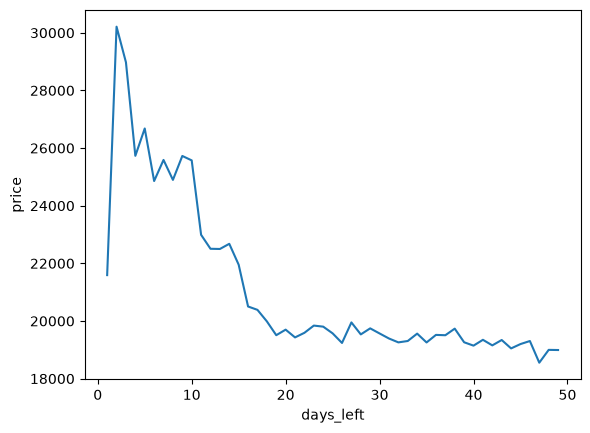

In [20]:
# 시각화 라이브러리 불러오기
import matplotlib.pyplot as plt

# 시각화 영역(fegure)
plt.figure()

# days_left의 price 데이터로 선 그래프(plot) 그리기
plt.plot(days_left['price'])

# x축 이름 붙이기
plt.xlabel('days_left')

# y축 이름 붙이기
plt.ylabel('price')

# 시각화 표기
plt.show()

In [21]:
# airline 별 평균 데이터
airline = df.groupby('airline').mean(numeric_only=True)
airline

,duration,days_left,price
airline,,,
AirAsia,8.941714,27.735184,4091.072742
Air_India,15.504235,25.497466,23507.019112
GO_FIRST,8.755380,27.430415,5652.007595
Indigo,5.795197,26.264309,5324.216303
SpiceJet,12.579767,24.122850,6179.278881
Vistara,13.326634,25.894532,30396.536302


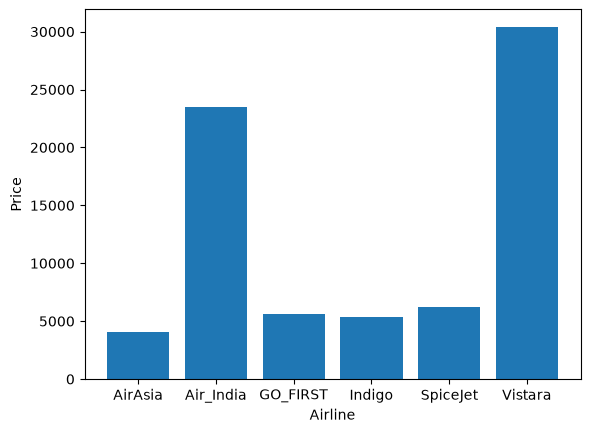

In [22]:
# 인덱스를 리스트로 만들기(x축 라벨로 사용)
label = airline.index

plt.figure()

# 인덱스를 x, 평균가격을 y로 사용
plt.bar(label, airline['price'])

plt.xlabel('Airline')

plt.ylabel('Price')

plt.show()

In [23]:
# 출발시간의 빈도
departure_time = df['departure_time'].value_counts()
departure_time

departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

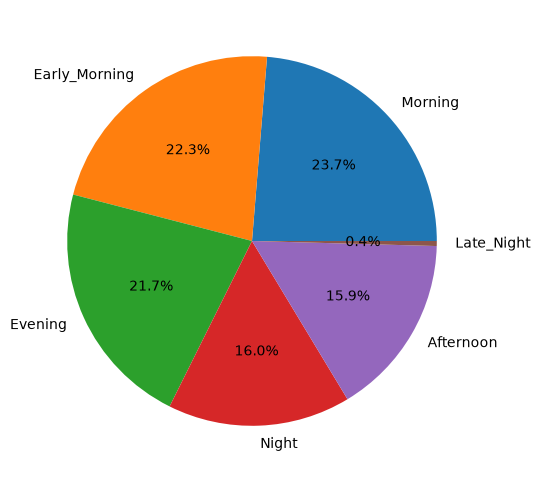

In [24]:
plt.figure(figsize=(10, 6))

# 파이 그래프 생성
plt.pie(departure_time, labels=departure_time.index, autopct='%.1f%%')

plt.show()

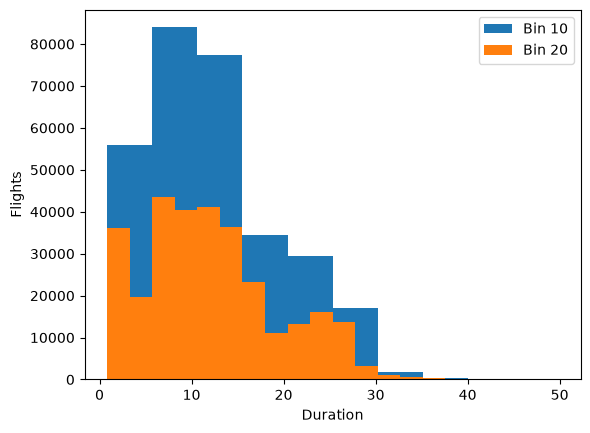

In [25]:
# 히스토그램
# bins - 몇개의 구간으로 나눌지
plt.figure()

# duration을 10개 구간으로 나눠서 히스토그램 그리기
plt.hist(df['duration'], bins=10)

# duration을 20개 구간으로 나눠서 히스토그램 그리기
plt.hist(df['duration'], bins=20)

plt.xlabel('Duration')

plt.ylabel('Flights')

# 동시에 2개의 그래프를 하나의 시각화 영역에 그려서 범례 지정하기(범례 = 우측 상단)
plt.legend(("Bin 10", "Bin 20"))
plt.show()

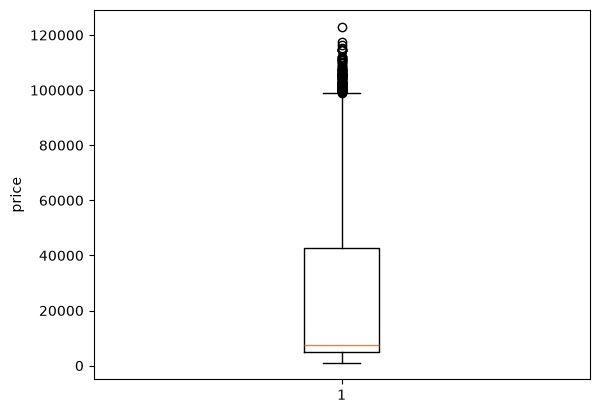

In [26]:
# boxplot - 사분위수를 중심으로 수치적 요약 통계 자료를 시각화
plt.figure()

# Price 컬럼에 대한 상자 그래프 그리기
plt.boxplot(df['price'])

plt.ylabel('price')

plt.show()

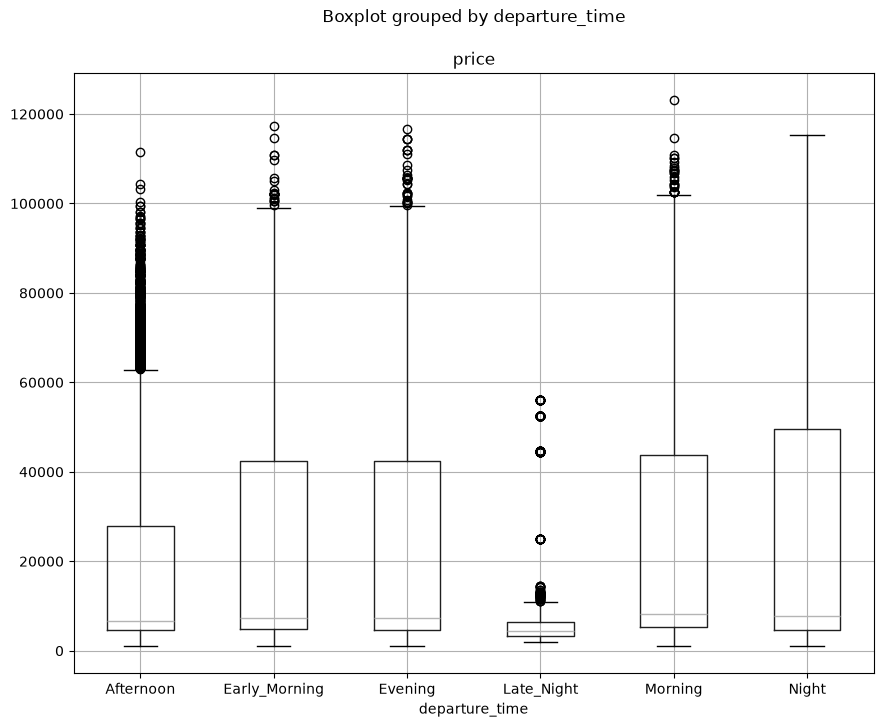

In [27]:
# 출발시간별로 가격에 대한 상자 그래프 그리기
df.boxplot(by='departure_time', column='price', figsize=(10,8))
plt.show()

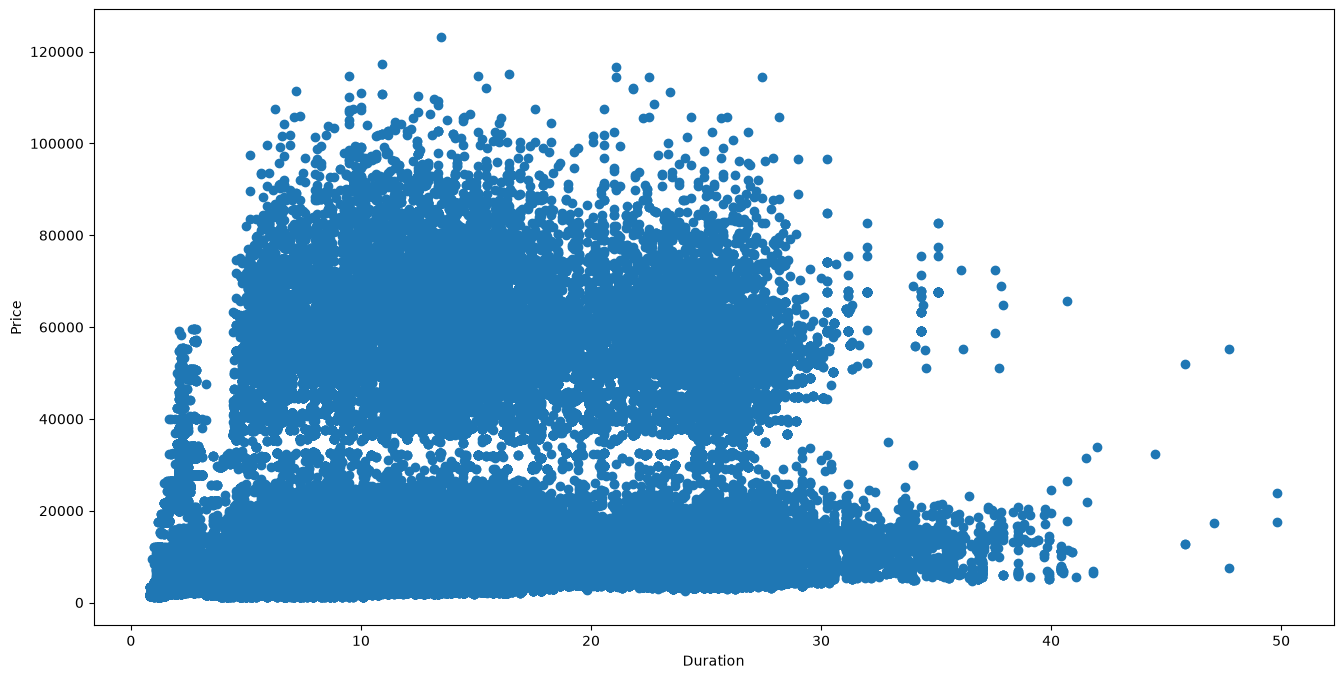

In [28]:
# 비행시간과 항공권가격의 관계
plt.figure(figsize=(16, 8))

# price와 duration의 산점도 그리기
plt.scatter(x=df['duration'], y=df['price'])

plt.xlabel('Duration')
plt.ylabel('Price')

plt.show()


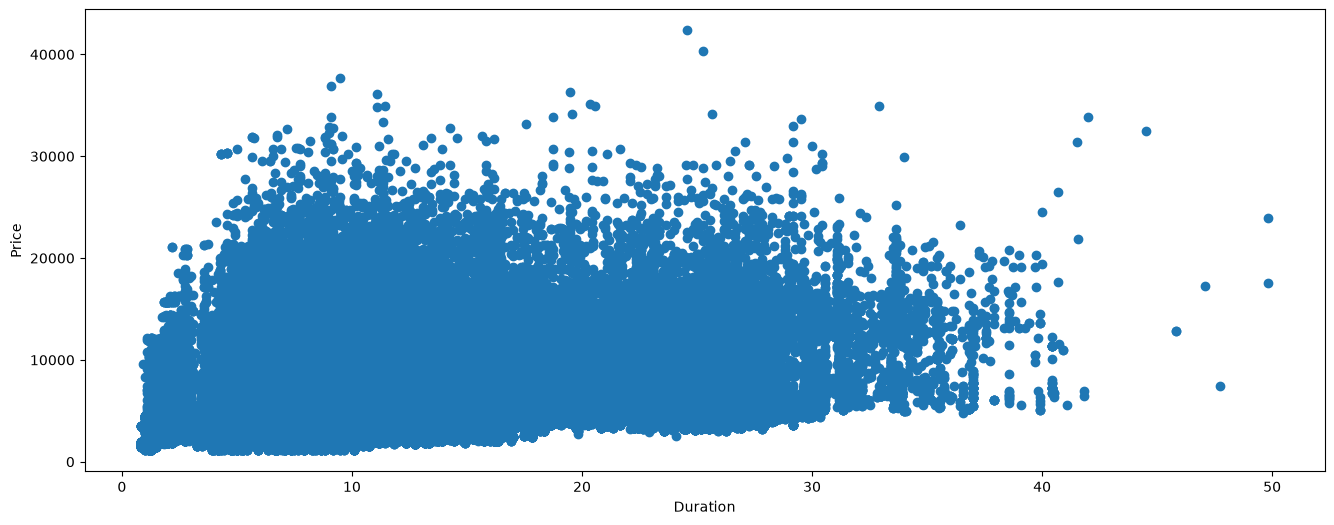

In [29]:
plt.figure(figsize=(16,6))

# Economy 클래스에 대한 price와 duration 간의 산점도 그리기
plt.scatter(y=df_eco['price'], x=df_eco['duration'])

plt.xlabel('Duration')

plt.ylabel('Price')

plt.show()

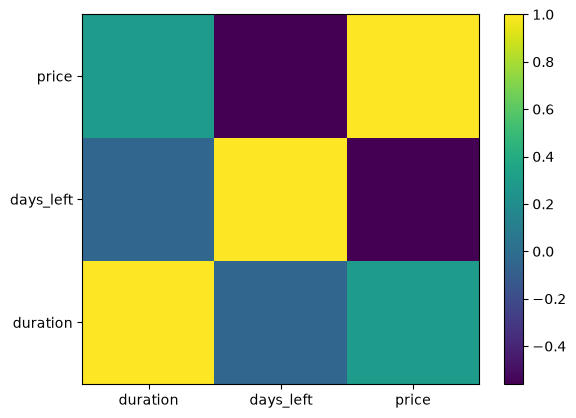

In [30]:
# 상관계수 데이터 만들기 
heat = df_eco.corr(numeric_only=True)

# 상관계수로 heatmap 그리기
plt.pcolor(heat)

# x축 항목 정보 표기하기
plt.xticks(np.arange(0.5, len(heat.columns), 1), heat.columns)

# y축 항목 정보 표기하기
plt.yticks(np.arange(0.5, len(heat.index), 1), heat.index)

# heatmap 확인을 위한 컬러바 표기하기
plt.colorbar()

plt.show()

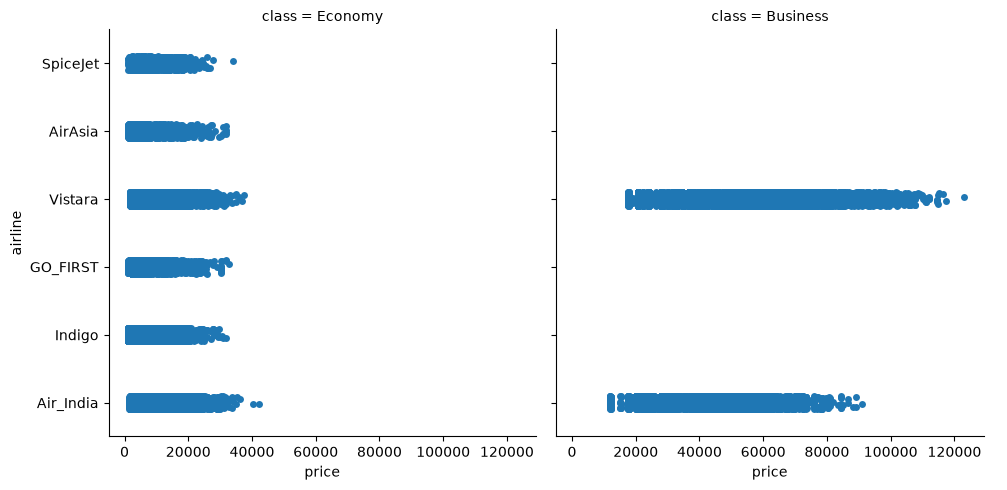

In [31]:
# seaborn 활용
# 범주형 산점도(categorical plot)
import seaborn as sns
# airline 별 price를 class 별로 구분하여 시각화
sns.catplot(data=df, x='price', y='airline', col='class')
plt.show()

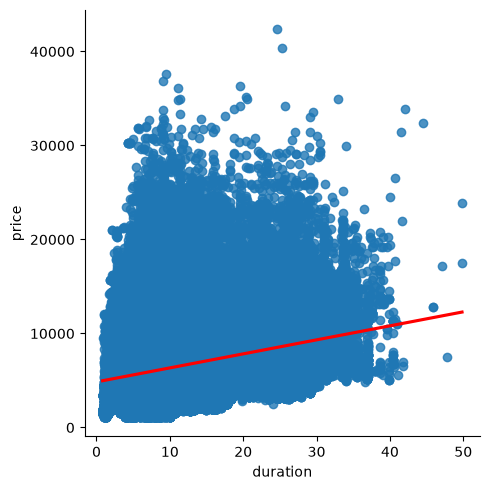

In [32]:
# 선형 회귀 모델(linear model plot)
# duration과 price의 회귀선을 빨간색으로 표시
sns.lmplot(data=df_eco, x='duration', y='price', line_kws={'color':'red'})
plt.show()

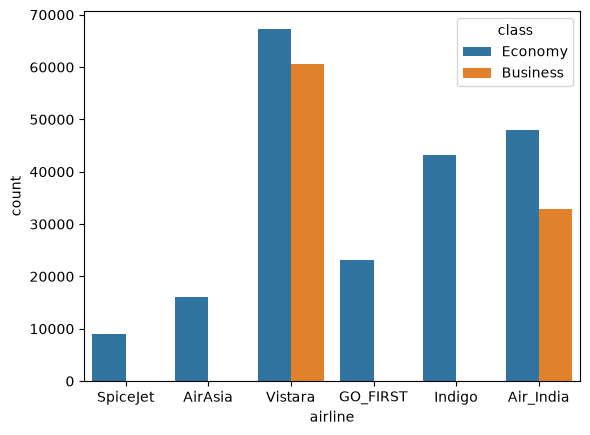

In [33]:
# 빈도 그래프(counts)
# 항공권 데이터의 빈도를 airline으로 구분하여 class 별로 시각화하기
sns.countplot(data=df, x='airline', hue='class')
plt.show()

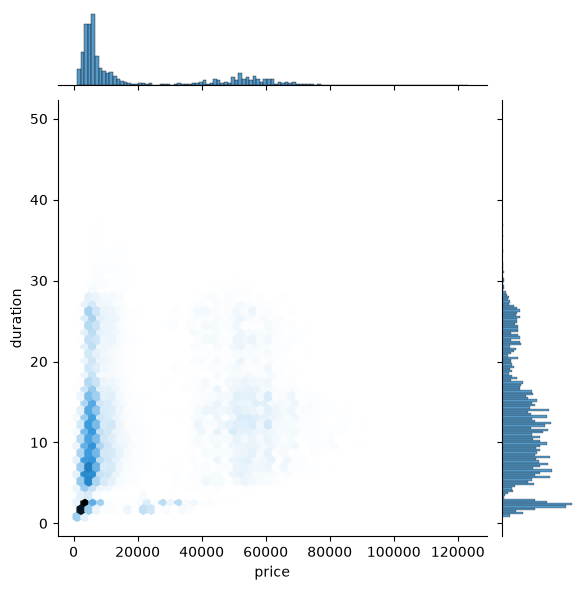

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
# 조인트 그래프 
# price 와 duration 의 관계를 조인트 그래프로 시각화하기
# kind 를 활용해 중앙 그래프를 변경하기도 가능
sns.jointplot(data=df, x='price', y='duration', kind='hex')
plt.show()

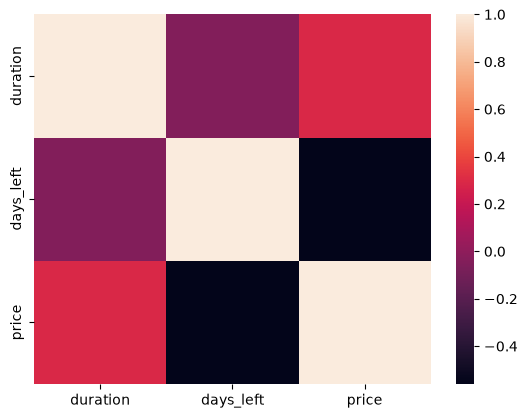

In [39]:
sns.heatmap(df_eco.corr(numeric_only=True))
plt.show()

<Axes: >

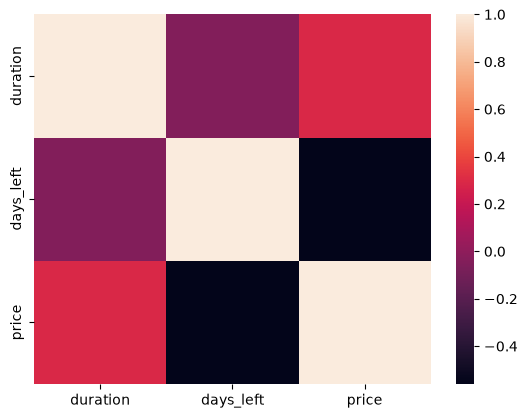

In [ ]:
test_economy = df[df['class']=='Economy']
plt.figure()
sns.heatmap(test_economy.corr(numeric_only=True))